### Changelog
v1.2.0 - 12th March
- Q2 - Added clarification on merging approach of the dataframes.
- Updated requirements.txt to include Scipy.

v1.1.0 - 8th March
- Q1 - Added clarification that you may need to modify the file ingestion lines (i.e. file) to handle data cleansing.
- Q1 - Added clarification on NSW inclusions from crime_data.csv.
- Q1 - Added clarification on output of police_stations_df.
- Q2 - Added clarification on the output df.
- Updated requirements.txt to include more packages.

## COMP9321 26T1 Assignment 1 v1.2.0 (15 marks)

The NSW Government provides the community with public datasets and research about crime. 

This assignment uses the following data:

- `police_stations.json`: Information about all police stations in NSW and ACT, from the Bureau of Crime Statistics and Research (BOCSAR).
- `crime_data.csv`: Criminal incident information in NSW about offences, locations, and their frequency over time, from the Department of Customer Service.
- `postcodes.json`: A list of Australian postcodes, from the user "Elkfox" on Github.

### Assignment Instructions

Failure to follow these rules may result in penalties during marking. 

#### Environment Setup
- Use the provided `requirements.txt` to set up your virtual environment.
- Use only libraries available in the virtual environment (e.g., `pandas`, `matplotlib`).
- Use Python **3.13** only (i.e., the version installed on CSE).

#### Your Answers!
In this assignment you will need to provide three types of answers as explained in each question:
- Dataframe/Table as an output
    - Use the code cell [https://jupyter-notebook.readthedocs.io/en/stable/notebook.html#code-cells] where you see **# YOUR CODE GOES HERE**. If the last line of your code is the result dataframe, the notebook will automatically display the results. 
- Plots (visualisations)
   - Use the code cell [https://jupyter-notebook.readthedocs.io/en/stable/notebook.html#code-cells] where you see **# YOUR CODE GOES HERE**. For plots/images you need to have **plt.show()** as the last line of your code. 
- Written Responses
  - Use the markdown cell [https://jupyter-notebook.readthedocs.io/en/stable/notebook.html#markdown-cells] where you see **⛔ DELETE THIS TEXT AND REPLACE WITH YOUR ANSWER ⛔**. That placeholder text should be removed and replaced with your response.  Format your responses using Markdown syntax [https://www.markdownguide.org/basic-syntax/].

#### Coding Standards
- Do **not** use `for` or `while` loops over DataFrame rows or Series.
- Do **not** convert DataFrames to native Python types (`list`, `dict`) for processing.
- Plots/Dataframes answering the questions must be shown in the notebook output. For each question, there must be ONLY a single code cell with your code to address each task and its output should reflect your answer. You must make sure you include all outputs before submitting your notebook file. 
- Do **not** modify the provided code template structure; instead add your code where indicated by "YOUR CODE GOES HERE"
- You may write helper functions inside the code cell for the question where it is used.
- Pandas Operations- Your solutions should leverage efficient native Pandas operations (such as apply, drop, read_csv, etc.) rather than manual or iterative approaches. Additionally, ensure that DataFrames are properly indexed and sorted to enhance readability and facilitate easier data exploration.

#### Visualisation Standards
For questions 4 and 5, make sure you:
- Choose a suitable chart type for the data.
- Use appropriate scale and colour.
- Include title, axis labels, and legend with readable sizing.
- Ensure the visualisation is self-explanatory and informative.
- You may use sub-plots inside one window to fit multiple visualisations.
#### Submission
- You can use WebCMS to submit your notebook file which should be named **zid.ipynb** (e.g., z123456.ipynb). You only need to submit the notebook file. Your notebook must not exceed 5MB. 
- Make sure you **include all the outputs** in the notebook file (run all cells before submission), otherwise you will be penalised by 50% of the maximum marks for that question.
- Late submission is permitted with a 5% penalty per day, and you can submit no later than 5 days late.

In [1]:
# Make sure you copy the dataset files to the same directory as your notbook

import warnings
from datetime import datetime

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# NOTE: If you need to import any other libraries, you can do so here,  
# provided they are available within the virtual environment.
# (see "Environment Setup" in the assignment instructions above)

import csv
import io
import re
from pyproj import Transformer

# Set display options and ignore warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 5)
pd.set_option("display.max_columns", None)

---

# Question 1 (3 marks)

---

You need to clean both the **crime_data_df** and **police_stations_df**  dataframes by applying best data wrangling practices. This includes, but is not limited to, checking for missing values, removing unnecessary columns, and any obvious data quality issues. It is part of the assignment to explore the dataset and the assignment requirements (including all questions) and clean the dataset as much as you can. **Do not clean the dataset files directly**, but instead read the file in and apply the transformations in your code.

*v1.1.0 update - you may need to modify the ingestion line (i.e., look inside the optional parameters for read_csv such as on_bad_lines), to clean the dataset to allow it to be loaded, before you can apply further cleaning to it.*

Only include data for NSW - exclude all other states and territories. 

*v1.1.0 update - the crime_data.csv file only includes data from NSW. This can be relied upon to achieve this.*

**crime_data_df** is a wide dataset and you are also tasked to transform **crime_data_df**; the transformed dataframe must include the following columns.

- `suburb`
- `category`
- `sub_category`
- `date`
- `crime_count`

You should populate the fields with their equivalent values from the original **crime_data_df**.

*v1.1.0 update -the police_stations_df dataset should only include the following columns.*

- `police_station_name`
- `EPSG_3857_x`
- `EPSG_3857_y`

**Marking Criteria**
- [2.5 marks] The dataframes are fully cleaned and transformed using the most efficient pandas operations. 
- [0.5 marks] The written responses for how any data quality issues have been identified and rectified are sound and complete.


## Crime dataset

In [2]:
# YOUR CODE GOES HERE - Clean the crime data dataframe, name it (crime_data_df) and show the dataframe as output of your cell

# repair csv
with open('crime_data.csv') as file:
    hearer_line = file.readline()

header_columns = next(csv.reader(io.StringIO(hearer_line)))
header_columns.insert(header_columns.index('Nov 1999') + 1, 'Dec 1999')

# read csv
crime_data_df = pd.read_csv(
    'crime_data.csv',
    names=header_columns,
    header=None,
    skiprows=1,
    on_bad_lines='skip',
    low_memory=False
    )

# rename columns 
crime_data_df = crime_data_df.rename(
    columns={
        'Suburb': 'suburb',
        'Offence category': 'category',
        'Subcategory': 'sub_category',
    }
)

# remove spaces in column names
crime_data_df['suburb'] = crime_data_df['suburb'].str.strip()
crime_data_df['category'] = crime_data_df['category'].str.strip()
crime_data_df['sub_category'] = crime_data_df['sub_category'].str.strip()

# melt the dataframe to have a long format
crime_data_df = crime_data_df.melt(
    id_vars=['suburb', 'category', 'sub_category'],
    var_name='date',
    value_name='crime_count'
)

# repair data types and date format
crime_data_df['crime_count'] = pd.to_numeric(
    crime_data_df['crime_count'],
    errors='coerce'
)

crime_data_df['crime_count'] = crime_data_df['crime_count'].fillna(0)

crime_data_df['crime_count'] = crime_data_df['crime_count'].astype(int)

crime_data_df['date'] = pd.to_datetime(
    crime_data_df['date'],
    format='%b %Y'
)

# remove crime_count = 0
crime_data_df = crime_data_df[crime_data_df['crime_count'] > 0]

# remove duplicate rows
crime_data_df = crime_data_df.drop_duplicates(subset=['suburb', 'category', 'sub_category', 'date'])
  
# sort
crime_data_df = crime_data_df.sort_values(by=['suburb', 'category', 'sub_category', 'date'])

# reset index
crime_data_df = crime_data_df.reset_index(drop=True)

# Do not change the following line of code (this will print the dataframe as an output after running the cell)
crime_data_df

,suburb,category,sub_category,date,crime_count
0,Aarons Pass,Against justice procedures,Breach Apprehended Violence Order,2022-12-01,1
1,Aarons Pass,Against justice procedures,Breach bail conditions,2024-03-01,1
...,...,...,...,...,...
6038538,Zetland,Transport regulatory offences,Transport regulatory offences,2023-02-01,1
6038539,Zetland,Transport regulatory offences,Transport regulatory offences,2025-07-01,1


In [3]:
# Do not change the following line of code (this will print the dataframe as an output after running the cell)
crime_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6038540 entries, 0 to 6038539
Data columns (total 5 columns):
 #   Column        Dtype         
---  ------        -----         
 0   suburb        object        
 1   category      object        
 2   sub_category  object        
 3   date          datetime64[ns]
 4   crime_count   int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 230.4+ MB


### ✍️ Written Response – Cleaning `crime_data_df`

**Instructions:**  
Provide concise bullet points under each heading below.  
Focus on *what issues were identified and why your cleaning decisions were appropriate*.  
Do not describe specific lines of code.

**Data Quality Issues Identified**
- csv header lack column of "Dec 1999"
- Some values in crime_count are not numeric.
- There are two abnormal rows in dataset: one row is missing a field, and another row has an extra field.
- This wide format is not suitable for time-related groupby operations.
- Exist one completely duplicated record.

**Cleaning Steps Applied**
- Repair csv by insert Dec 1999.
- Skip rows with missing or extra fields.
- Renamed columns.
- Remove whitespaces in text field.
- Change the wide format to long format.
- Repaired data types by converting crime_count to numeric and date to the correct datetime format.
- Remove row with crime_count = 0.
- Removed duplicated records.
- Sort the dataframe and reset index.

**Justification**
- Removing rows with crime_count = 0 reduces dataset size and improves processing speed.
- Change from wide format to long format can easily enables times-ralated grouping operations and easier to read.
- Removing duplicate rows can prevents row count for twice in the later analysis.
- Converting crime_count to numeric and date to the correct datetime format can ensure the dataset is suitable for further analysis.

## Police station dataset

In [4]:
# YOUR CODE GOES HERE - Clean the police stations dataframe, name it (police_stations_df) and show the dataframe as output of your cell
# police_stations_df = pd.read_json('police_stations.json')

# 1 read json and flatten the nested structure
raw_json = pd.read_json('police_stations.json')
police_stations_df = pd.json_normalize(raw_json['features'])

# 2 rename columns
police_stations_df = police_stations_df.rename(
    columns={
        'attributes.generalname': 'police_station_name',
        'geometry.x': 'EPSG_3857_x',
        'geometry.y': 'EPSG_3857_y'
    }
)

# 3 filter out police stations that are not in NSW, use postcode to filter

# postcode.json has state_code 
postcodes_df = pd.read_json("postcodes.json")

# change postcodes_df to GeoDataFrame
postcodes_gdf = gpd.GeoDataFrame(
    postcodes_df,
    geometry=gpd.points_from_xy(postcodes_df.longitude, postcodes_df.latitude),
    crs="EPSG:4326"
)

# change police_stations_df to GeoDataFrame
stations_gdf = gpd.GeoDataFrame(
    police_stations_df,
    geometry=gpd.points_from_xy(
        police_stations_df["EPSG_3857_x"],
        police_stations_df["EPSG_3857_y"]
    ),
    crs="EPSG:3857"
)

# change police stations to the same crs as postcodes 
stations_gdf = stations_gdf.to_crs("EPSG:4326")

# find the nearest postcode for each police station, and get the state_code of the nearest postcode by using sjoin_nearest
stations_joined = gpd.sjoin_nearest(
    stations_gdf,
    postcodes_gdf,
    how="left"
)

# filter out police stations that are not in NSW
stations_joined = stations_joined[stations_joined["state_code"] == "NSW"]

# change back to dataframe
police_stations_df = stations_joined[["police_station_name", "EPSG_3857_x", "EPSG_3857_y"]]

# 4 remove duplicate rows
police_stations_df = police_stations_df.drop_duplicates(subset=['police_station_name', 'EPSG_3857_x', 'EPSG_3857_y'])

# 5 sort
police_stations_df = police_stations_df.sort_values(by=['police_station_name'])

# 6 reset index
police_stations_df = police_stations_df.reset_index(drop=True)

# Do not change the following line of code
police_stations_df

,police_station_name,EPSG_3857_x,EPSG_3857_y
0,ADAMINABY POLICE STATION,1.656146e+07,-4.299915e+06
1,ADELONG POLICE STATION,1.648220e+07,-4.205795e+06
...,...,...,...
413,YETMAN POLICE STATION,1.678424e+07,-3.363074e+06
414,YOUNG POLICE STATION,1.650848e+07,-4.071180e+06


In [5]:
# Do not change the following line of code
police_stations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   police_station_name  415 non-null    object 
 1   EPSG_3857_x          415 non-null    float64
 2   EPSG_3857_y          415 non-null    float64
dtypes: float64(2), object(1)
memory usage: 9.9+ KB


### ✍️ Written Response – Cleaning `police_stations_df`

**Instructions:**  
Provide concise bullet points under each heading below.  
Focus on *what issues were identified and why your cleaning decisions were appropriate*.  
Do not describe specific lines of code.

**Data Quality Issues Identified**
- JSON data has a nested structure. We should  transforming and flattening.
- Mix with police stations not belong to NSW

**Cleaning Steps Applied**
- Read json and flatten the nested structure
- Rename columns
- Filter out police stations that are not in NSW by performing a nearest spatial join with postcode data
- Removed duplicated records.
- Sort the dataframe and reset index.

**Justification**
- Removing duplicate rows can prevents row count for twice in the later analysis.
- Structuring the dataset to improve readability for supporting further analysis.
- Spatial join can ensure correct geographic data to filter NSW police stations.

## Postcodes dataset (no action required)

In [6]:
# Do not change the following lines of code
postcodes_df = pd.read_json('postcodes.json')
postcodes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16875 entries, 0 to 16874
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   postcode    16875 non-null  int64  
 1   place_name  16875 non-null  object 
 2   state_name  16875 non-null  object 
 3   state_code  16875 non-null  object 
 4   latitude    16875 non-null  float64
 5   longitude   16875 non-null  float64
 6   accuracy    16871 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 923.0+ KB


---

# Question 2 (2 marks)

---

Merge the cleaned crime data and police stations dataframes into a single dataframe. Join the result dataframe with the postcodes dataset - the result dataframe should add four extra columns named `police_station_name`, and their WGS84 coordinates as `latitude`, `longitude` to the suburbs nearest police station, and `postcode`. 

All postcodes should be valid 4 digit values, or replaced as 9999 if not available.

*v1.1.0 update - the final output of this question, from left to right, would be:*
- The five columns in crime_data_df
- The three columns in police_stations_df
- The requested four new columns 

*Each row should be matched by using the available postcodes_df to find the appropriate police station for each suburb in the crime data.*

*v1.2.0 update - although the description above recommends a specific ordered merge approach, you may apply any operations in any order you wish to achieve the final outcome requested.*

**Marking Criteria**
- [1 mark]  The dataframes have been joined and cleaned successfully.
- [1 mark]  The nearest police stations are correct.

In [7]:
# YOUR CODE GOES HERE - name your output merged_df
merged_df = pd.DataFrame()

# 1 Build a suburb coordinate lookup table from postcode data and match it with crime suburbs
nsw_postcodes = postcodes_df[postcodes_df['state_code'] == 'NSW'].copy()

postcode_lookup = (
    nsw_postcodes.groupby('place_name')
    .agg({'latitude': 'mean', 'longitude': 'mean', 'postcode': 'first'})
    .reset_index()
)

# Remove bracketed content from suburb names
unique_suburbs = crime_data_df[['suburb']].drop_duplicates().copy()

unique_suburbs['clean_suburb'] = unique_suburbs['suburb'].str.replace(r"\s*\(.*?\)", "", regex=True)

# merge postcode to get suburb coordinates
unique_suburbs = unique_suburbs.merge(
    postcode_lookup,
    left_on='clean_suburb',
    right_on='place_name',
    how='left'
)

# 2 find closest police station
suburb_gdf = gpd.GeoDataFrame(
    unique_suburbs,
    geometry=gpd.points_from_xy(unique_suburbs.longitude, unique_suburbs.latitude),
    crs="EPSG:4326"
)

# Convert the coordinate system to EPSG:3857 for distance calculation
suburb_gdf = suburb_gdf.to_crs("EPSG:3857")

police_gdf = gpd.GeoDataFrame(
    police_stations_df,
    geometry=gpd.points_from_xy( police_stations_df.EPSG_3857_x, police_stations_df.EPSG_3857_y),
    crs="EPSG:3857"
)

nearest_station = gpd.sjoin_nearest(
    suburb_gdf,
    police_gdf,
    how='left',
    distance_col='distance'
)

# 3 build suburb lookup
suburb_station_lookup = nearest_station[[
    'clean_suburb',
    'postcode',
    'police_station_name',
    'EPSG_3857_x',
    'EPSG_3857_y'
]].drop_duplicates(subset='clean_suburb')

# postcode cleaning
suburb_station_lookup['postcode'] = pd.to_numeric(
    suburb_station_lookup['postcode'],
    errors='coerce'
)

# Set invalid postcodes (not between 2000 and 9999) to 9999
suburb_station_lookup.loc[
    ~suburb_station_lookup['postcode'].between(2000, 9999),
    'postcode'
] = 9999

suburb_station_lookup['postcode'] = suburb_station_lookup['postcode'].fillna(9999).astype(int)

# Change EPSG:3857 to WGS84 (latitude, longitude)
transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

suburb_station_lookup['longitude'], suburb_station_lookup['latitude'] = transformer.transform(
    suburb_station_lookup['EPSG_3857_x'].values,
    suburb_station_lookup['EPSG_3857_y'].values
)

# 4 merge crime data
crime_data_df['clean_suburb'] = crime_data_df['suburb'].str.replace(r"\s*\(.*?\)", "", regex=True)

merged_df = crime_data_df.merge(
    suburb_station_lookup,
    on='clean_suburb',
    how='left'
)

# 5 merge
merged_df = merged_df[[
    'suburb',
    'category',
    'sub_category',
    'date',
    'crime_count',

    'police_station_name',
    'EPSG_3857_x',
    'EPSG_3857_y',

    'postcode',
    'latitude',
    'longitude'

]]

# Do not change the following line of code
merged_df

,suburb,category,sub_category,date,crime_count,police_station_name,EPSG_3857_x,EPSG_3857_y,postcode,latitude,longitude
0,Aarons Pass,Against justice procedures,Breach Apprehended Violence Order,2022-12-01,1,MUDGEE POLICE STATION,1.665147e+07,-3.840994e+06,2850,-32.589886,149.582731
1,Aarons Pass,Against justice procedures,Breach bail conditions,2024-03-01,1,MUDGEE POLICE STATION,1.665147e+07,-3.840994e+06,2850,-32.589886,149.582731
...,...,...,...,...,...,...,...,...,...,...,...
6038538,Zetland,Transport regulatory offences,Transport regulatory offences,2023-02-01,1,REDFERN POLICE STATION,1.683150e+07,-4.014310e+06,2017,-33.892003,151.199911
6038539,Zetland,Transport regulatory offences,Transport regulatory offences,2025-07-01,1,REDFERN POLICE STATION,1.683150e+07,-4.014310e+06,2017,-33.892003,151.199911


---

# Question 3 (4 marks)

---

NSW Police want to better understand how to allocate their resources in the upcoming financial year (1 July 2026 to 30 June 2027). They need your help to digest crime trends across NSW into actionable outcomes. This should be aimed at senior police executives, who are time-poor and not trained at reading large and complex datasets.

You are tasked with building a summary table that helps NSW Police understand the police stations with the highest number of incidents for each crime, and their offence rates. Consider how this has changed over time, and also the variance between different parts of NSW. Ensure the information is easily digestible - do not overwhelm the reader with large responses. At the same time, do not cut out details which can bias your conclusions.

**Marking Criteria**
- [2 marks] A suitable dataframe as an output to fullfil the requirement.
- [2 marks] An accurate, detailed, and relevant analysis of your results — remark on what conclusions you can draw from the output dataframe.

In [8]:
# YOUR CODE GOES HERE - your pivot table should be named summary_df
# summary_df = pd.DataFrame()

# 1. information about year
merged_df['year'] = merged_df['date'].dt.year
n_years = merged_df['year'].nunique()

# 2. create pivot_table
station_cat = pd.pivot_table(
    merged_df,
    values='crime_count',
    index='police_station_name',
    columns='category',
    aggfunc='sum',
    fill_value=0
)

# 3. top station for each crime category
top_stations_names = station_cat.idxmax(axis=0).rename('top_station')
top_totals = station_cat.max(axis=0).rename('top_incidents').astype(int)

# 4. annual crime rate for top station
annual_rate =(top_totals / n_years).round(2).rename('annual_offence_rate')

# 5. Average Crime Rate (Last 3 Years vs Previous 3 Years) — Trend (Crime Rate Change)
# 2023 - 2025 vs 2016 - 2018
recent_pivot = (
    pd.pivot_table(
        merged_df[merged_df['year'].between(2023, 2025)],
        values='crime_count',
        index='police_station_name',
        columns='category',
        aggfunc='sum',
        fill_value=0
    )
    /5
)

past_pivot = (
    pd.pivot_table(
        merged_df[merged_df['year'].between(2016, 2018)],
        values='crime_count',
        index='police_station_name',
        columns='category',
        aggfunc='sum',
        fill_value=0
    )
    /5
)

recent_pivot = recent_pivot.reindex(columns=station_cat.columns, fill_value=0)
past_pivot = past_pivot.reindex(columns=station_cat.columns, fill_value=0)

# values for the top station
# Identify the top station and calculate its average annual crime rate in the two time periods
recent_rates = pd.Series({
    cat: recent_pivot.loc[top_stations_names[cat], cat]
    for cat in station_cat.columns
})

past_rates = pd.Series({
    cat: past_pivot.loc[top_stations_names[cat], cat]
    for cat in station_cat.columns
})

# summary_df
summary_df = pd.concat([
    top_stations_names.rename('top_station'),
    top_totals.rename('total_incidents'),
    annual_rate.rename('annual_offence_rate'),
    recent_rates.rename('recent three year crime rate'),
    past_rates.rename('earlier three year crime rate')
], axis=1)

# sort by annual offence rate
summary_df = summary_df.sort_values('total_incidents', ascending=False)

# offence_rate_chang
summary_df['offence_rate_change'] = (
    (summary_df['recent three year crime rate'] - summary_df['earlier three year crime rate'])
    / summary_df['earlier three year crime rate'] * 100
).round(2)

# crime variance across NSW
nsw_std_dev = station_cat.std(axis=0).rename('crime variance across NSW')
summary_df = summary_df.join(nsw_std_dev)

# crime concentration/ proportion of NSW incidents from the top police station in each crime category
summary_df['crime_concentration'] = (
    summary_df['total_incidents'] /
    station_cat.sum(axis=0)
).round(3)

# Handle infinite values in offence_rate_change (when earlier three year crime rate is 0)
summary_df['offence_rate_change'] = summary_df['offence_rate_change'].replace(np.inf, 100)

pd.set_option('display.max_rows', 50)
# Do not change the following lines of code

summary_df


,top_station,total_incidents,annual_offence_rate,recent three year crime rate,earlier three year crime rate,offence_rate_change,crime variance across NSW,crime_concentration
Theft,DAY STREET POLICE STATION,359090,11583.55,2738.8,4814.6,-43.11,37832.304026,0.041
Transport regulatory offences,BLACKTOWN POLICE STATION,167496,5403.10,3817.6,8666.8,-55.95,14344.883281,0.103
Malicious damage to property,BLACKTOWN POLICE STATION,62659,2021.26,658.0,1022.2,-35.63,8952.275356,0.026
Assault,BLACKTOWN POLICE STATION,59973,1934.61,1139.4,1206.6,-5.57,7793.085509,0.031
Against justice procedures,CAMPBELLTOWN POLICE STATION,54614,1761.74,1356.6,1700.6,-20.23,6658.705828,0.036
Drug offences,DAY STREET POLICE STATION,38376,1237.94,967.6,1399.6,-30.87,4358.885961,0.039
"Intimidation, stalking and harassment",BLACKTOWN POLICE STATION,27262,879.42,776.4,573.4,35.40,3247.763682,0.033
Other offences,DAY STREET POLICE STATION,25430,820.32,261.8,489.8,-46.55,2132.512467,0.047
Liquor offences,DAY STREET POLICE STATION,24086,776.97,296.8,782.4,-62.07,1780.077890,0.074
Disorderly conduct,DAY STREET POLICE STATION,21418,690.90,441.8,477.4,-7.46,2326.325039,0.034


### ✍️ Written Response – Question 3

**Instructions:**  
Provide a concise executive-level analysis supported by your summary table (150–300 words recommended).  
Use bullet points where appropriate.  
Focus on insights, not code description.

- Theft is the most significant crime category and the top station is in the central of Sydney. This phenomenon indicates that citizen and police station should pay more attention to high-density urban areas.
- Major crime categories show a declining trend. This indicates that public safety has steadily improved significantly.
- Crime is concentrated in a several police stations like 'DAY STREET POLICE STATION' and 'BLACKTOWN POLICE STATION'. The police should strengthen public safety within the jurisdictions of these police stations.
- Several crime types are increasing. Police should figure out the reasons and try to control the growing speed.
- Crime variance across NSW is high. This indicates that crime is unevenly distributed. Some areas has significatantly higher crime levels than others.
- Extreme growth rates in low base case (Blackmail and extortion) can be observsed. The increase of online scams and extortion could be the major reason.
- A base effect is present (Coercive Control), which can lead to a wrong infinity offence rate change. These values are set at 100% to maintain a realistic and useful comparison.

---

# Question 4 (3 marks)

---

Provide actionable recommendations for the general public supported by appropriate visualisation(s) for how crime changes across Sydney during a typical calendar year. Feel free to create subplots within a single view to support your recommendations.

**Marking Criteria:**
- [2 marks] The visualisation, and your accompanying explanation, has depth and relevance to the community about crime changes during a typical calendar year in Sydney.
- [1 mark] The visualisation maintains a professional standard of visual quality, clarity, formatting, and correctness.



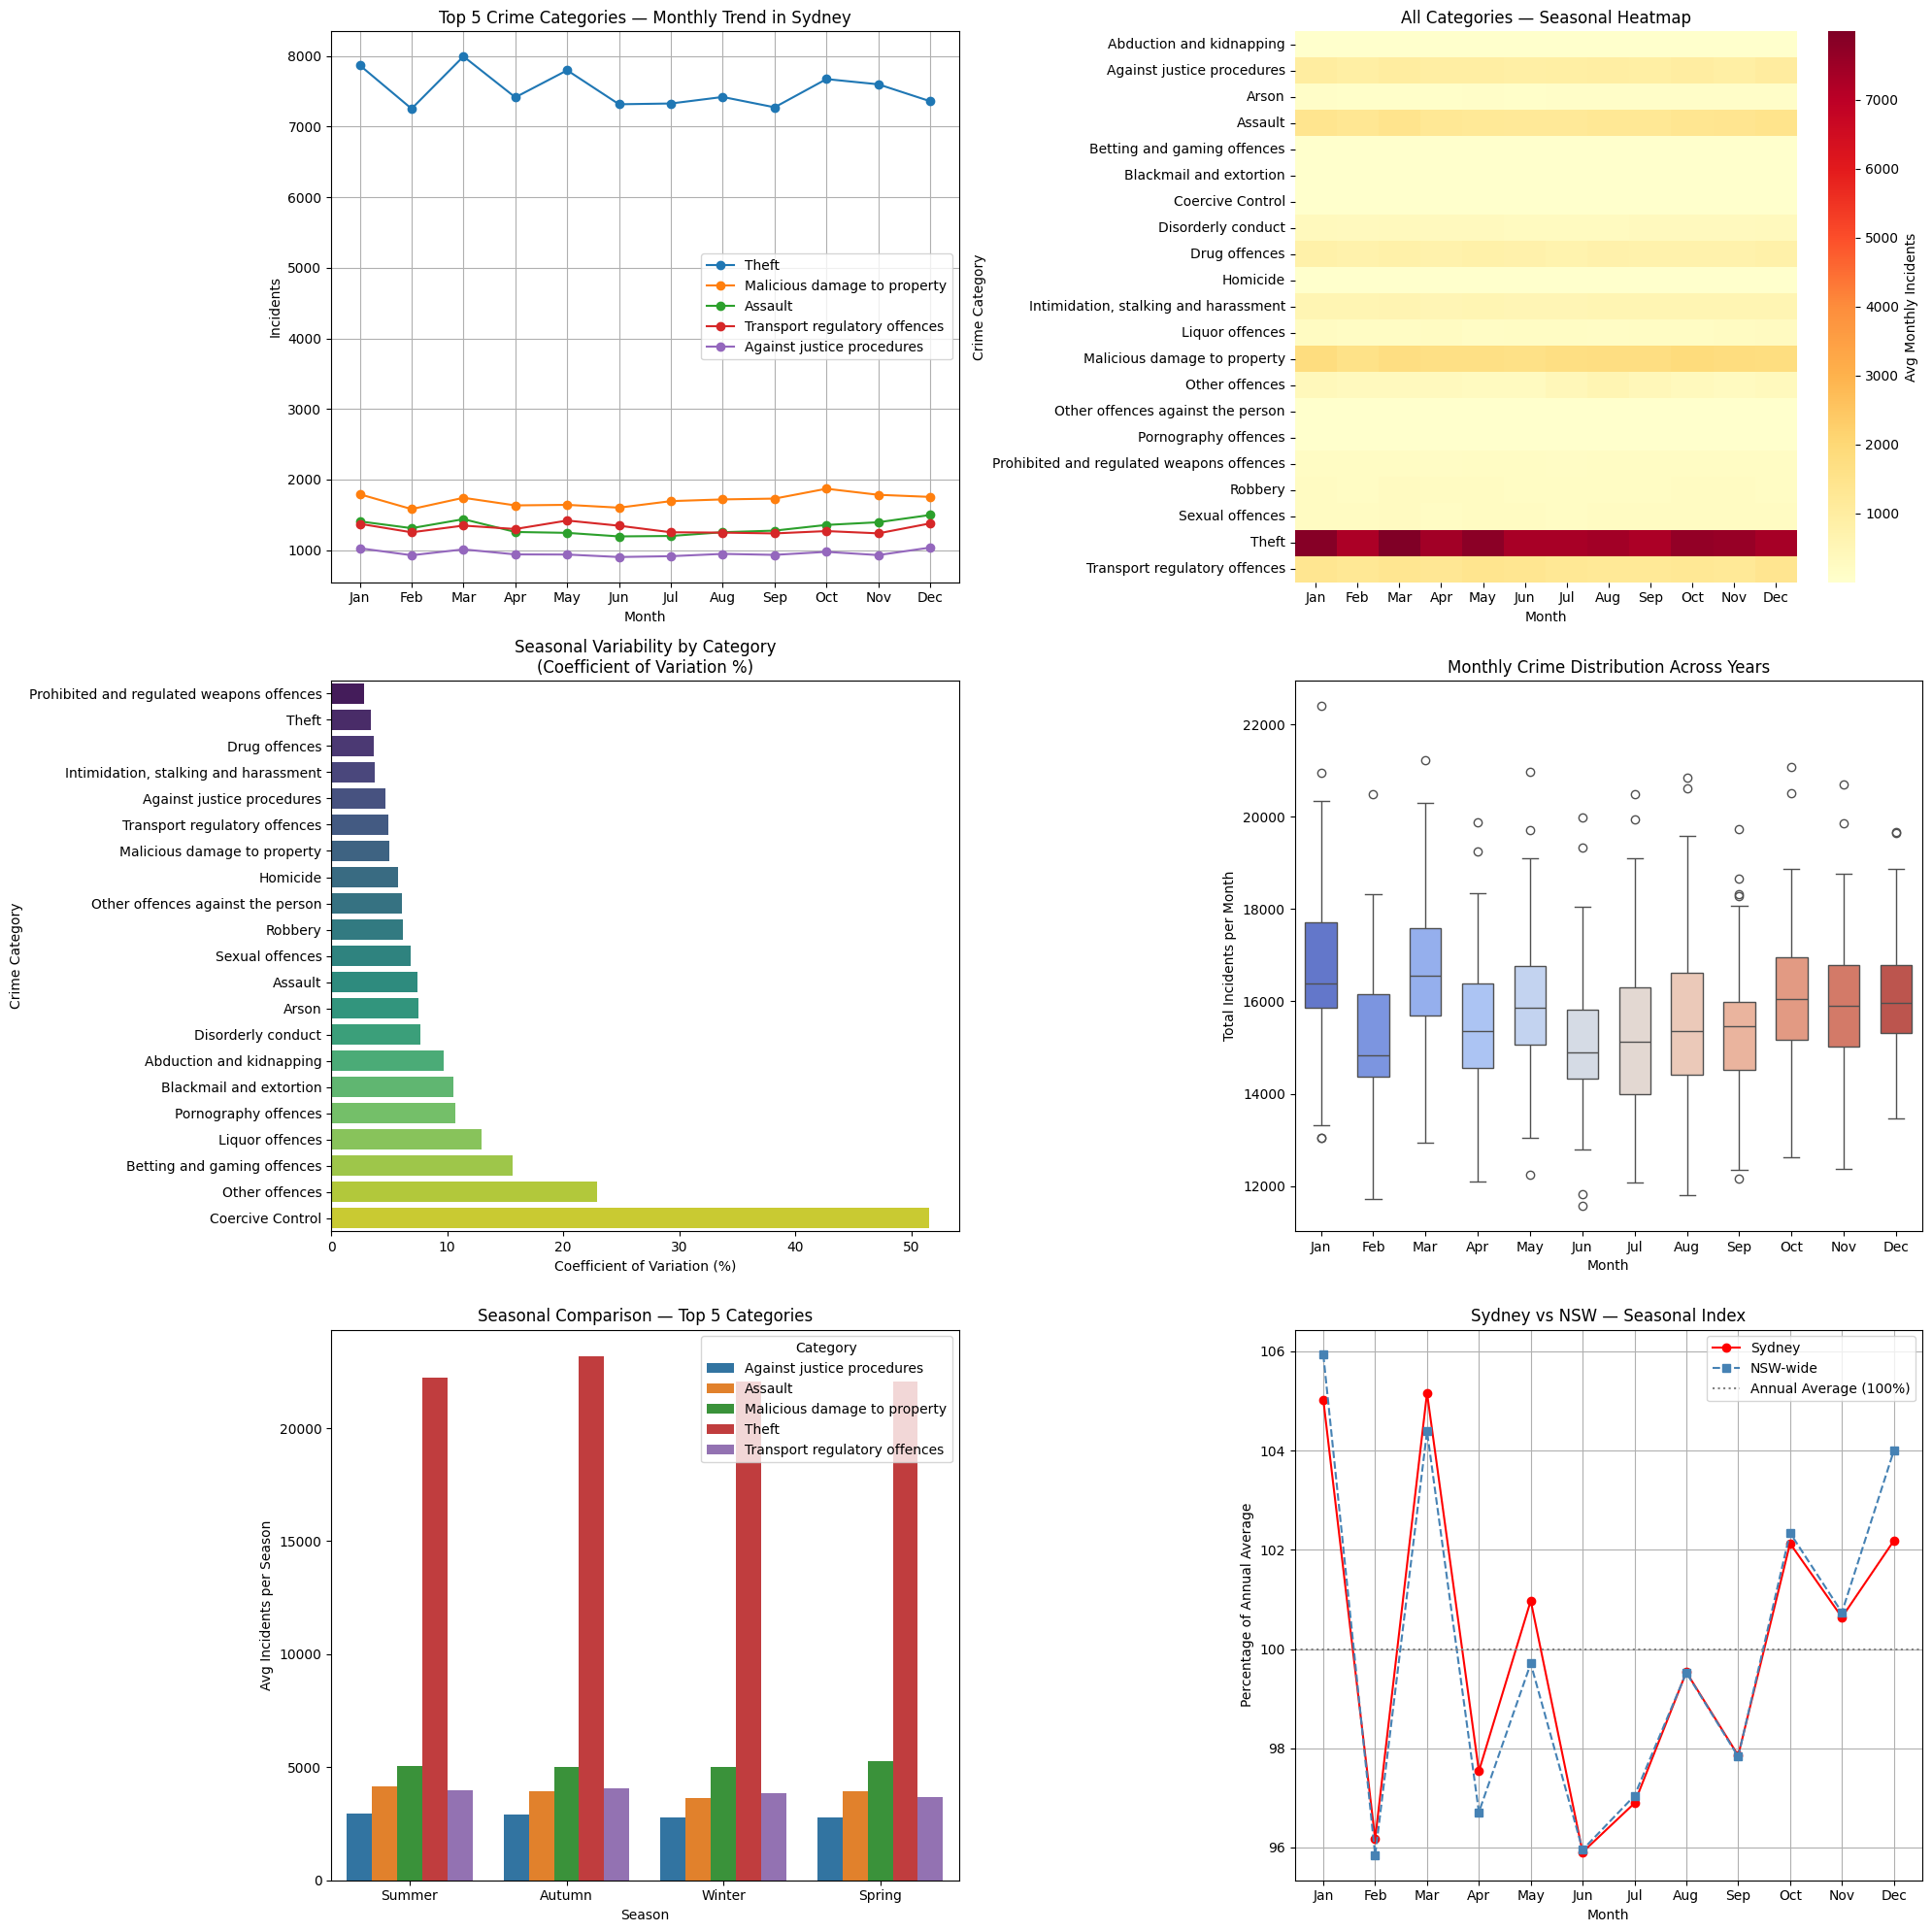

In [9]:
# 1. prepare data for graphs
merged_df['date'] = pd.to_datetime(merged_df['date'])

# filter Sydney by postcode (2000-2234)
sydney_df = merged_df[merged_df['postcode'].between(2000, 2234)].copy()

# get month and year
sydney_df['month'] = sydney_df['date'].dt.month
sydney_df['year'] = sydney_df['date'].dt.year

# 2. create graphs

# graph1: Line chart - Monthly Trend for Top 5 Crime Categories in Sydney

# find Top5 crime
top5_categories = (
    sydney_df.groupby('category')['crime_count']
    .sum()
    .nlargest(5)
    .index
)
# only keep Top5
top_df = sydney_df[sydney_df['category'].isin(top5_categories)]

# Calculate average monthly crime trend by category
monthly_yearly = (
    top_df.groupby(['year','month','category'])['crime_count']
    .sum()
    .reset_index()
)
monthly_trend = (
    monthly_yearly.groupby(['month','category'])['crime_count']
    .mean()
    .reset_index()
)

# graph2 heatmap - seasonal pattern for all categories

# Calculate average monthly crime trend by category
heatmap_yearly = (
    sydney_df.groupby(['year','month','category'])['crime_count']
    .sum()
    .reset_index()
)
heatmap_data = (
    heatmap_yearly.groupby(['category','month'])['crime_count']
    .mean()
    .unstack()
)

# graph3 seasonal variability (coefficient of variation)

# Calculate average monthly crime trend by category
category_month_avg = (
    heatmap_yearly.groupby(['category','month'])['crime_count']
    .mean()
    .reset_index()
)

# Calculate mean and std for each category
cv_data = (
    category_month_avg.groupby('category')['crime_count']
    .agg(['mean','std'])
    .reset_index()
)

# Calculate cv%
cv_data['cv'] = (cv_data['std'] / cv_data['mean']) * 100

# sort cv
cv_data = cv_data.sort_values('cv')

# graph4 boxplot - monthly crime distribution across years

monthly_total = (
    sydney_df.groupby(['year','month'])['crime_count']
    .sum()
    .reset_index()
)

# graph5 seasonal comparison - top 5 categories

# create season
def get_season(month):
    if month in [12,1,2]:
        return 'Summer'
    elif month in [3,4,5]:
        return 'Autumn'
    elif month in [6,7,8]:
        return 'Winter'
    else:
        return 'Spring'

sydney_df['season'] = sydney_df['month'].apply(get_season)

# only keep Top5 crimes
season_top_df = sydney_df[sydney_df['category'].isin(top5_categories)]

# Calculate average monthly crime trend by category
season_yearly = (
    season_top_df.groupby(['year','season','category'])['crime_count']
    .sum()
    .reset_index()
)
season_data = (
    season_yearly.groupby(['season','category'])['crime_count']
    .mean()
    .reset_index()
)

# set season order
season_order = ['Summer','Autumn','Winter','Spring']

season_data['season'] = pd.Categorical(
    season_data['season'],
    categories=season_order,
    ordered=True
)

# graph6 seasonal index - Sydney vs nsw

# Sydney average monthly 
sydney_month_avg = (
    sydney_df.groupby(['year','month'])['crime_count']
    .sum()
    .groupby('month')
    .mean()
    .reset_index(name='sydney_avg')
)

# Sydney annual monthly average
sydney_annual_avg = sydney_month_avg['sydney_avg'].mean()

# Sydney seasonal index
sydney_month_avg['sydney_index'] = (
    sydney_month_avg['sydney_avg'] / sydney_annual_avg
) * 100


# NSW-wide data
nsw_df = merged_df.copy()
nsw_df['date'] = pd.to_datetime(nsw_df['date'])
nsw_df['year'] = nsw_df['date'].dt.year
nsw_df['month'] = nsw_df['date'].dt.month

nsw_month_avg = (
    nsw_df.groupby(['year','month'])['crime_count']
    .sum()
    .groupby('month')
    .mean()
    .reset_index(name='nsw_avg')
)

# NSW annual monthly average
nsw_annual_avg = nsw_month_avg['nsw_avg'].mean()

# NSW seasonal index
nsw_month_avg['nsw_index'] = (
    nsw_month_avg['nsw_avg'] / nsw_annual_avg
) * 100

# 3. draw graphs

#  set size
fig, axes = plt.subplots(3,2, figsize=(20,20))

# flatten to use
axes = axes.flatten()

# first graph - monthly trend for top 5 crime categories in Sydney
ax = axes[0]
for cat in top5_categories: 
    
    data = monthly_trend[monthly_trend['category'] == cat]
    
    ax.plot(
        data['month'],
        data['crime_count'],
        marker='o',
        label=cat
    )

ax.set_xticks(range(1,13))
ax.set_xticklabels(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)

ax.set_title('Top 5 Crime Categories — Monthly Trend in Sydney')
ax.set_xlabel('Month')
ax.set_ylabel('Incidents')

ax.legend()
ax.grid(True)

# second graph - seasonal pattern for all categories (heatmap)

heat = sns.heatmap(
    heatmap_data,
    ax=axes[1],
    cmap='YlOrRd'
)

# colorbar label (right side)
heat.collections[0].colorbar.set_label('Avg Monthly Incidents')

# Month (x-axis)
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

axes[1].set_xlabel('Month')

# show crime category on the left
axes[1].set_ylabel('Crime Category')

axes[1].set_title('All Categories — Seasonal Heatmap')

# third graph - seasonal variability (coefficient of variation)

sns.barplot(
    data=cv_data,
    y='category',
    x='cv',
    palette='viridis',
    ax=axes[2]
)

axes[2].set_title('Seasonal Variability by Category\n(Coefficient of Variation %)')
axes[2].set_xlabel('Coefficient of Variation (%)')
axes[2].set_ylabel('Crime Category')

# fourth graph - monthly crime distribution across years (boxplot)
sns.boxplot(
    data=monthly_total,
    x='month',
    y='crime_count',
    ax=axes[3],
    palette='coolwarm',
    width=0.6
)

axes[3].set_xticks(range(0,12))
axes[3].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

axes[3].set_title('Monthly Crime Distribution Across Years')
axes[3].set_xlabel('Month')
axes[3].set_ylabel('Total Incidents per Month')

# fifth graph - seasonal comparison - top 5 categories
sns.barplot(
    data=season_data,
    x='season',
    y='crime_count',
    hue='category',
    palette='tab10',
    ax=axes[4]
)

axes[4].set_title('Seasonal Comparison — Top 5 Categories')
axes[4].set_xlabel('Season')
axes[4].set_ylabel('Avg Incidents per Season')

axes[4].legend(title='Category')

# sixth graph - seasonal index - sydney vs nsw

axes[5].plot(
    sydney_month_avg['month'],
    sydney_month_avg['sydney_index'],
    marker='o',
    color='red',
    label='Sydney'
)

axes[5].plot(
    nsw_month_avg['month'],
    nsw_month_avg['nsw_index'],
    marker='s',
    linestyle='--',
    color='steelblue',
    label='NSW-wide'
)

# annual average line
axes[5].axhline(
    y=100,
    color='gray',
    linestyle=':',
    label='Annual Average (100%)'
)

axes[5].set_xticks(range(1,13))
axes[5].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

axes[5].set_title('Sydney vs NSW — Seasonal Index')
axes[5].set_xlabel('Month')
axes[5].set_ylabel('Percentage of Annual Average')

axes[5].legend()
axes[5].grid(True)

# show graphs
plt.tight_layout()
plt.show()

### ✍️ Written Response – Question 4

**Instructions:**  
Provide clear, public-facing recommendations supported by your visualisation (150–300 words recommended).

Overall, according to the sixth graph, crime in Sydney shows a clear seasonal pattern in a year, with higher levels obseverd in the early months (January and March) and the months in the end of years(October to December). Meanwhile, crime rate is relatively low in the middle of years. More specifically, according to the fourth graph, monthly crime levels vary across the year. Higher median values observed in January, March, and October to December. And the lowest median values in the graph is June. In addition, the spread of the data indicates that some months experience greater variability.
Consider from the perspective of crime categories. Graph one, two and five shows that theft has highest incidence rate throughout the whole typical year with noticeable fluctuations, especially during peak periods like January and March. Similarly, significant seasonal variations can also be observed in other crimes. 

As the seasonal comparison chart shows, Autumn(March to may) is the peak of theft and some other crimes. One possible reason is that people in Sydney like to do outdoor activity in Autumn while leaving their homes unattended. Moreover, the heat map shows that crimes other than those with high crime rates remain relatively stable throughout the year. 

In summary, these graphs and the analysis highlights this two important findings: 1. January and March are peak crime months. 2. Theft is the most common crime category. Residents and the police in Sydney should be more cautious about these phenomena.

---

# Question 5 (3 marks)

---

NSW Police would like to investigate if there are offences in recent years that could present an increased risk to the community in the coming years. As a data analyst, your task is to verify or challenge the following claim:

> Major crimes have generally decreased throughout NSW in recent years. However, some crimes in specific areas have observed a significant increase.

Feel free to create subplots within a single view to support your recommendations.

**Marking Criteria:**
- [2 marks] The visualisation, and your accompanying explanation, effectively identifies trends and patterns that thorough verify or challenge the claim.
- [1 mark] The visualisation maintains a professional standard of visual quality, clarity, formatting, and correctness.



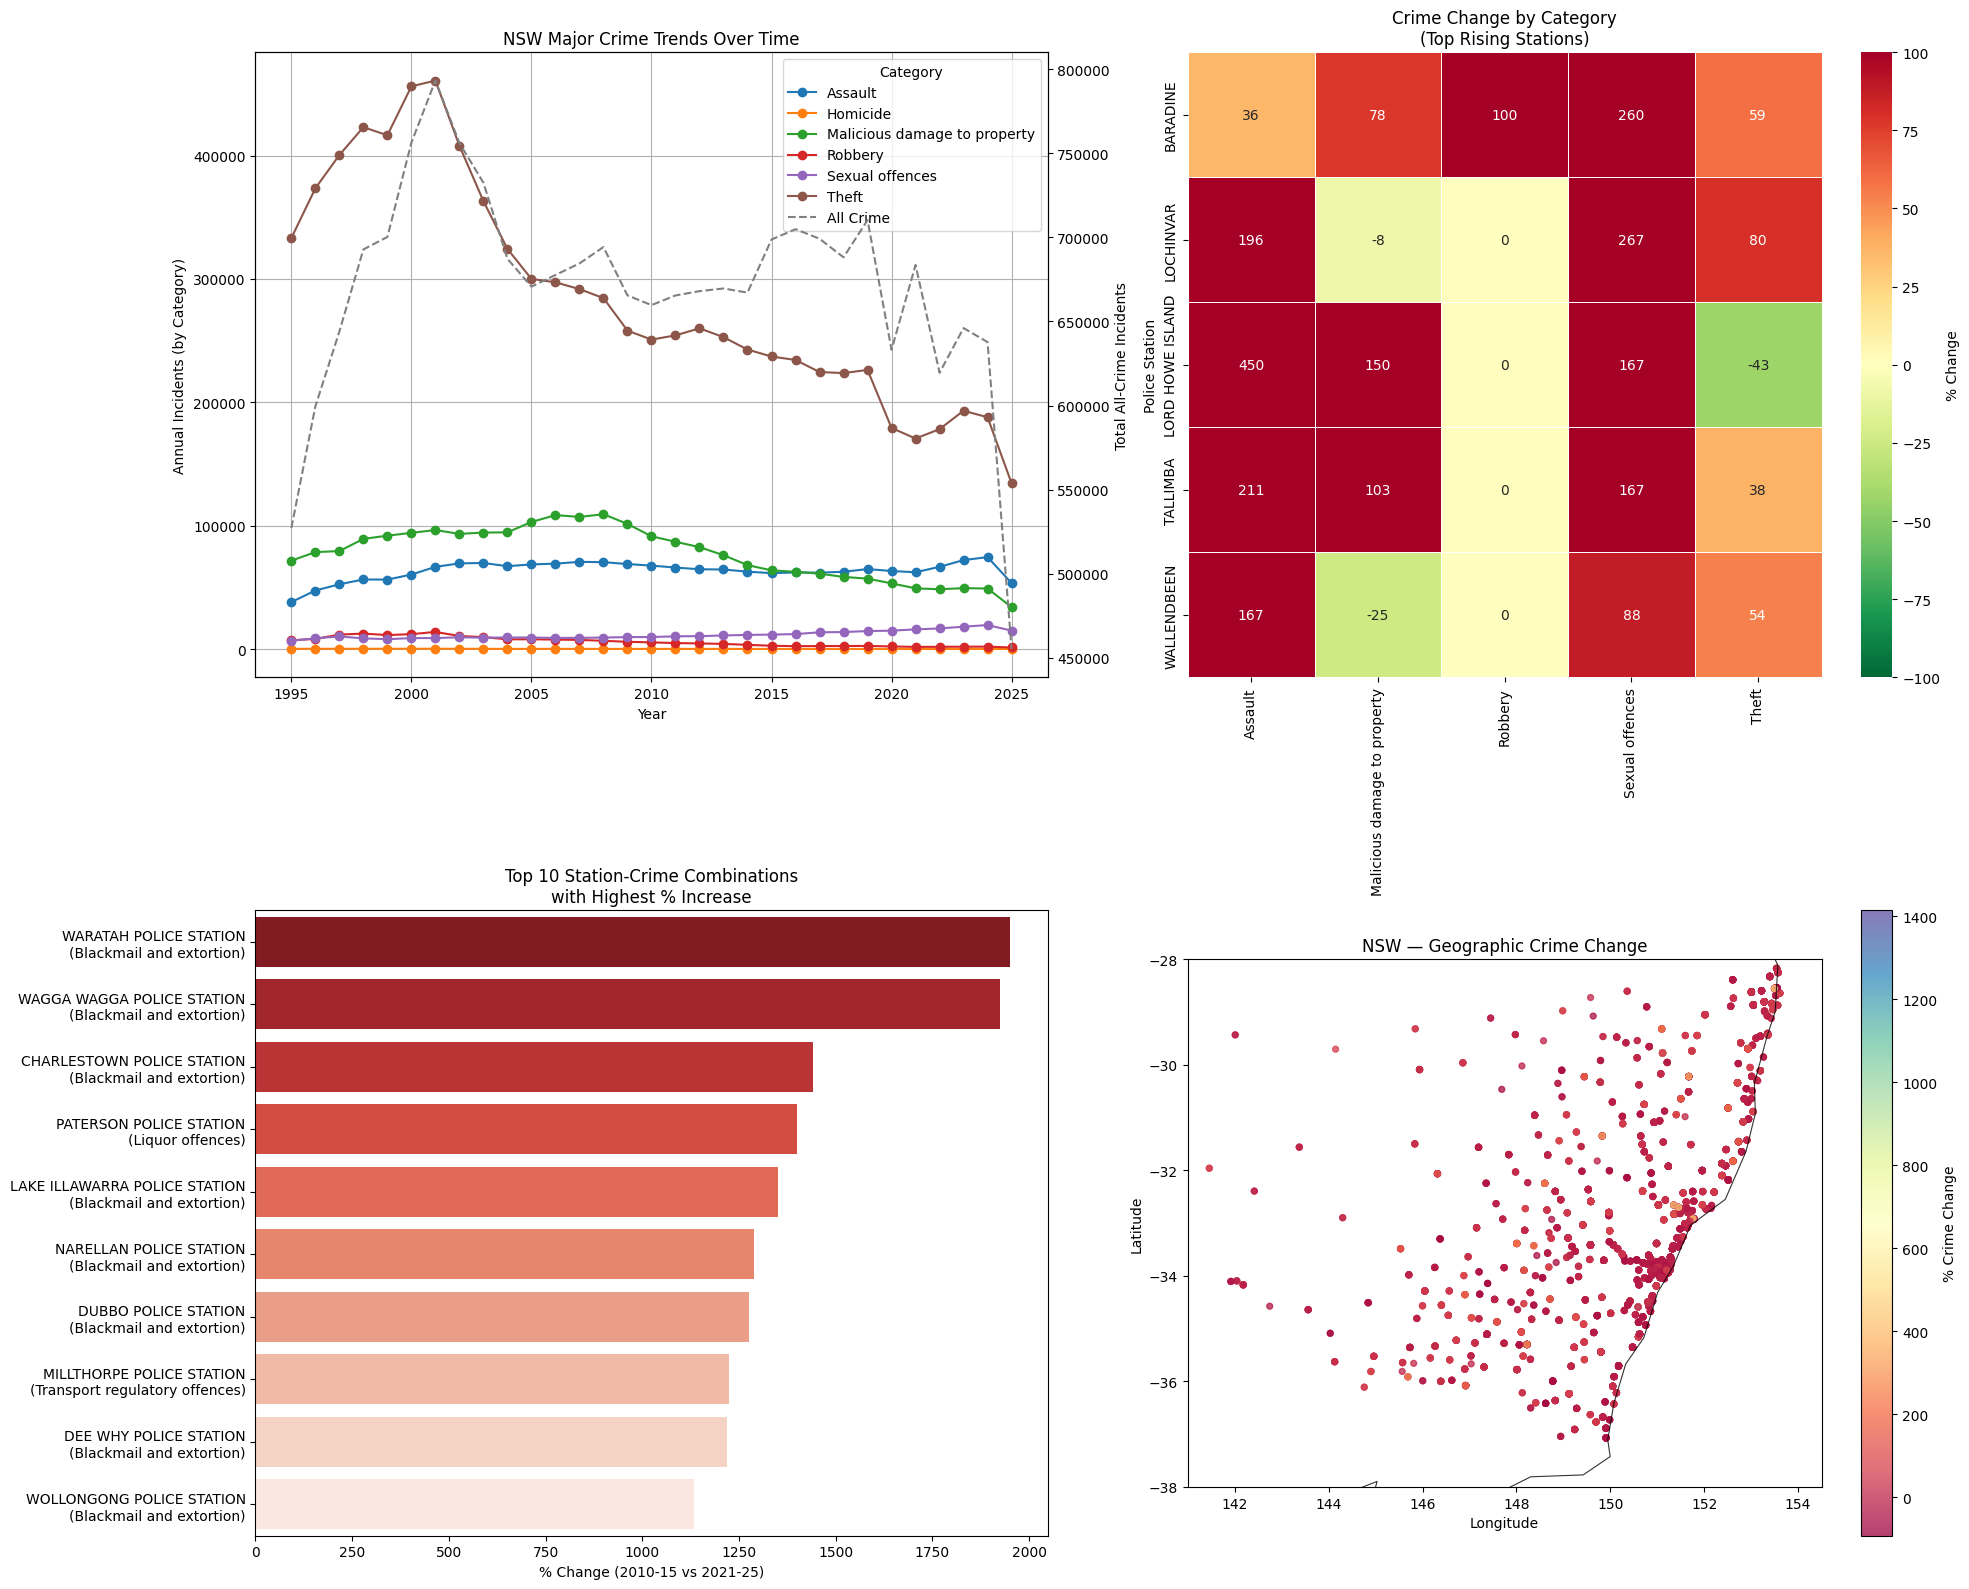

In [10]:
# 1. prepare data

merged_df['date'] = pd.to_datetime(merged_df['date'])

merged_df['year'] = merged_df['date'].dt.year


# 2. create graphs

# graph1 major crime trends

major_categories = [
    'Assault',
    'Homicide',
    'Malicious damage to property',
    'Robbery',
    'Sexual offences',
    'Theft'
]

# only keep major crimes
major_df = merged_df[
    merged_df['category'].isin(major_categories)
]

# yearly crime counts by category
category_yearly = (
    major_df.groupby(['year','category'])['crime_count']
    .sum()
    .reset_index()
)

# NSW overall crime trend
total_yearly = (
    merged_df.groupby('year')['crime_count']
    .sum()
    .reset_index()
)

# graph2 crime change heatmap (major crimes only)

major_categories = [
    'Assault',
    'Homicide',
    'Malicious damage to property',
    'Robbery',
    'Sexual offences',
    'Theft'
]

major_df = merged_df[
    merged_df['category'].isin(major_categories)
]

# calculate station yearly crime 

station_year = (
    major_df.groupby(['police_station_name','year'])['crime_count']
    .sum()
    .reset_index()
)

# early vs recent period

early_station = (
    station_year[
        station_year['year'].between(2010,2015)
    ]
    .groupby('police_station_name')['crime_count']
    .mean()
)

recent_station = (
    station_year[
        station_year['year'].between(2021,2025)
    ]
    .groupby('police_station_name')['crime_count']
    .mean()
)

# station % change

station_change = (
    (recent_station - early_station) / early_station * 100
).dropna()

# filter out stations with very low early crime counts to avoid extreme % change due to small numbers
station_change = station_change[early_station > 5]

# Top Rising Stations

top_stations = (
    station_change.sort_values(ascending=False)
    .head(5)
    .index
)

# station × category yearly

station_cat_year = (
    major_df.groupby(['police_station_name','category','year'])['crime_count']
    .sum()
    .reset_index()
)

# early period
early_cat = (
    station_cat_year[
        station_cat_year['year'].between(2010,2015)
    ]
    .groupby(['police_station_name','category'])['crime_count']
    .mean()
)

# recent period
recent_cat = (
    station_cat_year[
        station_cat_year['year'].between(2021,2025)
    ]
    .groupby(['police_station_name','category'])['crime_count']
    .mean()
)

# % change

pct_change = (
    (recent_cat - early_cat) / early_cat * 100
).reset_index(name='pct_change')

pct_change = pct_change.replace([np.inf, -np.inf], np.nan).dropna()

# only keep top stations
pct_change = pct_change[
    pct_change['police_station_name'].isin(top_stations)
]

# pivot heatmap

heatmap_matrix = pct_change.pivot(
    index='police_station_name',
    columns='category',
    values='pct_change'
)

# fill 0
heatmap_matrix = heatmap_matrix.fillna(0)

# rename
heatmap_matrix.index = heatmap_matrix.index.str.replace(
    " POLICE STATION", "", regex=False
)

# graph3 station-crime increase analysis

station_yearly = (
    merged_df.groupby(['police_station_name','category','year'])['crime_count']
    .sum()
    .reset_index()
)

# early period (2010–2015)
early_period = (
    station_yearly[
        station_yearly['year'].between(2010,2015)
    ]
    .groupby(['police_station_name','category'])['crime_count']
    .mean()
    .reset_index(name='early_avg')
)

# recent period (2021–2025)
recent_period = (
    station_yearly[
        station_yearly['year'].between(2021,2025)
    ]
    .groupby(['police_station_name','category'])['crime_count']
    .mean()
    .reset_index(name='recent_avg')
)

# merge
growth_df = pd.merge(
    early_period,
    recent_period,
    on=['police_station_name','category']
)

# percentage increase
growth_df['pct_increase'] = (
    (growth_df['recent_avg'] - growth_df['early_avg'])
    / growth_df['early_avg']
) * 100

# remove divide-by-zero cases
growth_df = growth_df.replace([np.inf, -np.inf], np.nan).dropna()

# top 10 increases
top10_growth = (
    growth_df.sort_values('pct_increase', ascending=False)
    .head(10)
)

# graph4 geographic crime change

location_yearly = (
    merged_df.groupby(['suburb','latitude','longitude','year'])['crime_count']
    .sum()
    .reset_index()
)

# early period (2010–2015)
early_geo = (
    location_yearly[
        location_yearly['year'].between(2010,2015)
    ]
    .groupby(['suburb','latitude','longitude'])['crime_count']
    .mean()
    .reset_index(name='early_avg')
)

# recent period (2021–2025)
recent_geo = (
    location_yearly[
        location_yearly['year'].between(2021,2025)
    ]
    .groupby(['suburb','latitude','longitude'])['crime_count']
    .mean()
    .reset_index(name='recent_avg')
)

# merge
geo_change = pd.merge(
    early_geo,
    recent_geo,
    on=['suburb','latitude','longitude']
)

# percentage change
geo_change['pct_change'] = (
    (geo_change['recent_avg'] - geo_change['early_avg'])
    / geo_change['early_avg']
) * 100

geo_change = geo_change.replace([np.inf, -np.inf], np.nan).dropna()

# 3. draw graphs

fig, axes = plt.subplots(2,2, figsize=(20,16))

axes = axes.flatten()


# Graph 1 — NSW Major Crime Trends Over Time

ax = axes[0]

# draw major crime lines
for cat in major_categories:
    
    data = category_yearly[
        category_yearly['category'] == cat
    ]
    
    ax.plot(
        data['year'],
        data['crime_count'],
        marker='o',
        label=cat
    )

ax.set_title('NSW Major Crime Trends Over Time')

ax.set_xlabel('Year')
ax.set_ylabel('Annual Incidents (by Category)')

ax.grid(True)


# second axis (total crime)

ax2 = ax.twinx()

ax2.plot(
    total_yearly['year'],
    total_yearly['crime_count'],
    linestyle='--',
    color='gray',
    label='All Crime'
)

ax2.set_ylabel('Total All-Crime Incidents')


# combine legends

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines + lines2,
    labels + labels2,
    title='Category'
)


# Graph 2 — Crime Change Heatmap

ax = axes[1]

sns.heatmap(
    heatmap_matrix,
    cmap="RdYlGn_r",
    center=0,
    vmin=-100,              
    vmax=100,                
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "% Change"},
    ax=ax
)

ax.set_title("Crime Change by Category\n(Top Rising Stations)")
ax.set_xlabel("")
ax.set_ylabel("Police Station")

# Graph 3 — Station-Crime % Increase

ax = axes[2]

# label
top10_growth['label'] = (
    top10_growth['police_station_name']
    + '\n('
    + top10_growth['category']
    + ')'
)

sns.barplot(
    data=top10_growth,
    x='pct_increase',
    y='label',
    palette='Reds_r',
    ax=ax
)

ax.set_title('Top 10 Station-Crime Combinations\nwith Highest % Increase')

ax.set_xlabel('% Change (2010-15 vs 2021-25)')
ax.set_ylabel('')

# Graph 4 — Geographic Crime Change
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

aus = world[world["ADMIN"] == "Australia"]

ax = axes[3]

# plot Australia boundary
aus.boundary.plot(
    ax=ax,
    color="#000000",        
    linewidth=0.8,
    alpha=0.8
)

# plot crime change points
scatter = ax.scatter(
    geo_change["longitude"],
    geo_change["latitude"],
    c=geo_change["pct_change"],
    cmap="Spectral",   
    s=18,
    alpha=0.75
)

# limit to NSW
ax.set_xlim(141, 154.5)
ax.set_ylim(-38, -28)

ax.set_title("NSW — Geographic Crime Change")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("% Crime Change")

plt.tight_layout()
plt.show()

### ✍️ Written Response – Question 5

**Instructions:**  
Evaluate the claim using evidence from your analysis (150–300 words recommended).

Overall, according to the graph1, major crime categories (theft, robbery, and malicious damage to property) in NSW show generally decrease since 2000s，theft. This indicates that overall public safety have a steady upward trend. However, crime like sexual offence and assualt facing a increasing trend. 

Moreover, from several police station like WARATAH POLICE STATION, WAGGA WAGGA POLICE STATION and CHARLESTOWN POLICE STATION in garph 3, a steady increase in blackmail and extortion can be observed. This indicate that with the rapid develop of technology, blackmail and extortion has become easier to commit. To address this issue, both public and the police should take preventive measures and be well prepared. To be more specific，according to the graph4, which shows the geographic distribution of crime changes across NSW，the increases are more significant in urban areas.Therefore, residents and the police in urben area should pay greater attention to the issue.

In summary, while the overall crime rate is significate declined, some crimes are increasing in some specific police stations according to graph2. This suggest that potenual risks is still exist.


---

*End of Assignment*